<a href="https://colab.research.google.com/github/renzzirven/Asynch_Activity-/blob/main/Copy_of_NAIVE_BAYES_SIMULATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**NAIVE BAYES CLASSIFIER**

**Naive Bayes** is a supervised machine learning classification algorithm that predicts the category of a data point using probability. It assumes that all features are independent of each other.It's goal is to calculate the probability of the target variable "Y" equals a particular class label "y" given an "X" set of features.

Naive Bayes is "naive" as it assumes that predictors in its model are conditionally independent, or unrelated to any of the other feature. It also assumes that all features contribute equally to the outcome.

Although this is unrealistic, it makes the classification problem simpler and more computationally tractable.


Here is one of the sample Naive Bayes simulation we found online. We added visualizations for us to understand the dataset better.

In [ ]:
import numpy as np #For numerical operations
import pandas as pd #For data handling (tables, CSV)
from google.colab import files #File uploader
from sklearn.model_selection import train_test_split #for splitting dataset into training and testing sets
from sklearn.metrics import confusion_matrix, classification_report #for evaluation tools
import matplotlib.pyplot as plt #for visualizations

In [ ]:
#Upload data set
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
data = pd.read_csv(file_name)

# Remove useless column
data = data.drop(columns=['Unnamed: 32'], errors='ignore')

# Define X and y properly
X = data.drop(columns=['id', 'diagnosis'])
y = data['diagnosis']
#For data insprection
print("First 5 rows:")
print(data.head())

print("\nDataset shape:", data.shape)
print("\nMissing values:")
print(data.isnull().sum())

Saving data.csv to data (3).csv
First 5 rows:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_w

In [ ]:
#Defining features and target variables
X = data.drop(columns=['id', 'diagnosis']) #id is not useful and diagnosis is our y
y = data['diagnosis']

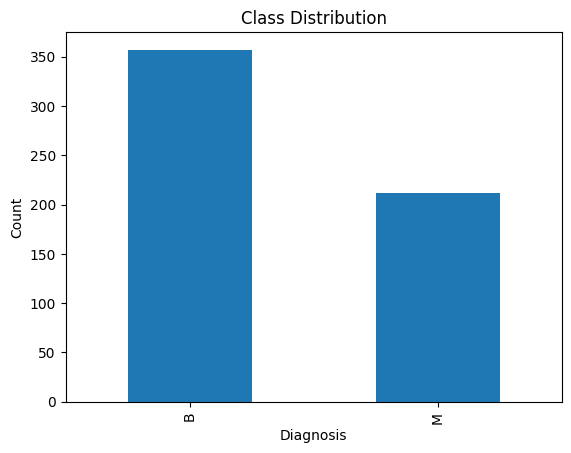

In [ ]:
#Visualizing class distributions
y.value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()


In [ ]:
#Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
class NaiveBayes:
    def fit(self, X_train, y_train):
        self.classes = np.unique(y_train)
        self.priors = [len(y_train[y_train == c]) / len(y_train) for c in self.classes]

        self.means = [X_train[y_train == c].mean() for c in self.classes]
        self.stds = [X_train[y_train == c].std() + 1e-9 for c in self.classes]
        # +1e-9 prevents division by zero

    def compute_likelihood(self, row, class_idx):
        likelihood = 1
        for feature in row.index:
            mean = self.means[class_idx][feature]
            std = self.stds[class_idx][feature]

            exponent = np.exp(-((row[feature] - mean) ** 2) / (2 * std ** 2))
            gaussian = (1 / (np.sqrt(2 * np.pi) * std)) * exponent
            likelihood *= gaussian

        return likelihood

    def predict(self, X):
        y_pred = []
        for _, row in X.iterrows():
            posteriors = []
            for i in range(len(self.classes)):
                likelihood = self.compute_likelihood(row, i)
                posterior = likelihood * self.priors[i]
                posteriors.append(posterior)

            y_pred.append(self.classes[np.argmax(posteriors)])

        return np.array(y_pred)


In [ ]:
#Training the Naive Bayes model
nb = NaiveBayes()
nb.fit(X_train, y_train)
predictions = nb.predict(X_test)

In [ ]:
#Evaluating accuracy
accuracy = np.mean(predictions == y_test) * 100
print(f"\nAccuracy: {accuracy:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, predictions))

cm = confusion_matrix(y_test, predictions)
print("\nConfusion Matrix:")
print(cm)


Accuracy: 96.49%

Classification Report:
              precision    recall  f1-score   support

           B       0.96      0.99      0.97        71
           M       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


Confusion Matrix:
[[70  1]
 [ 3 40]]


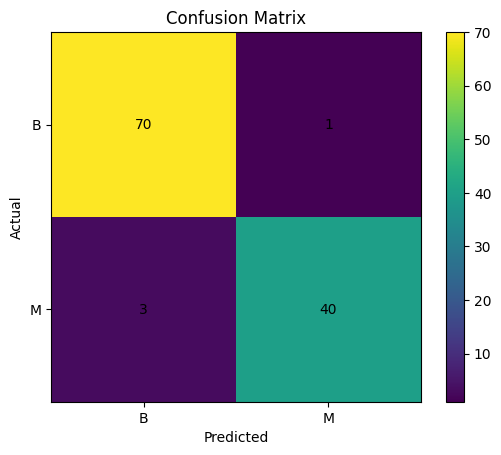

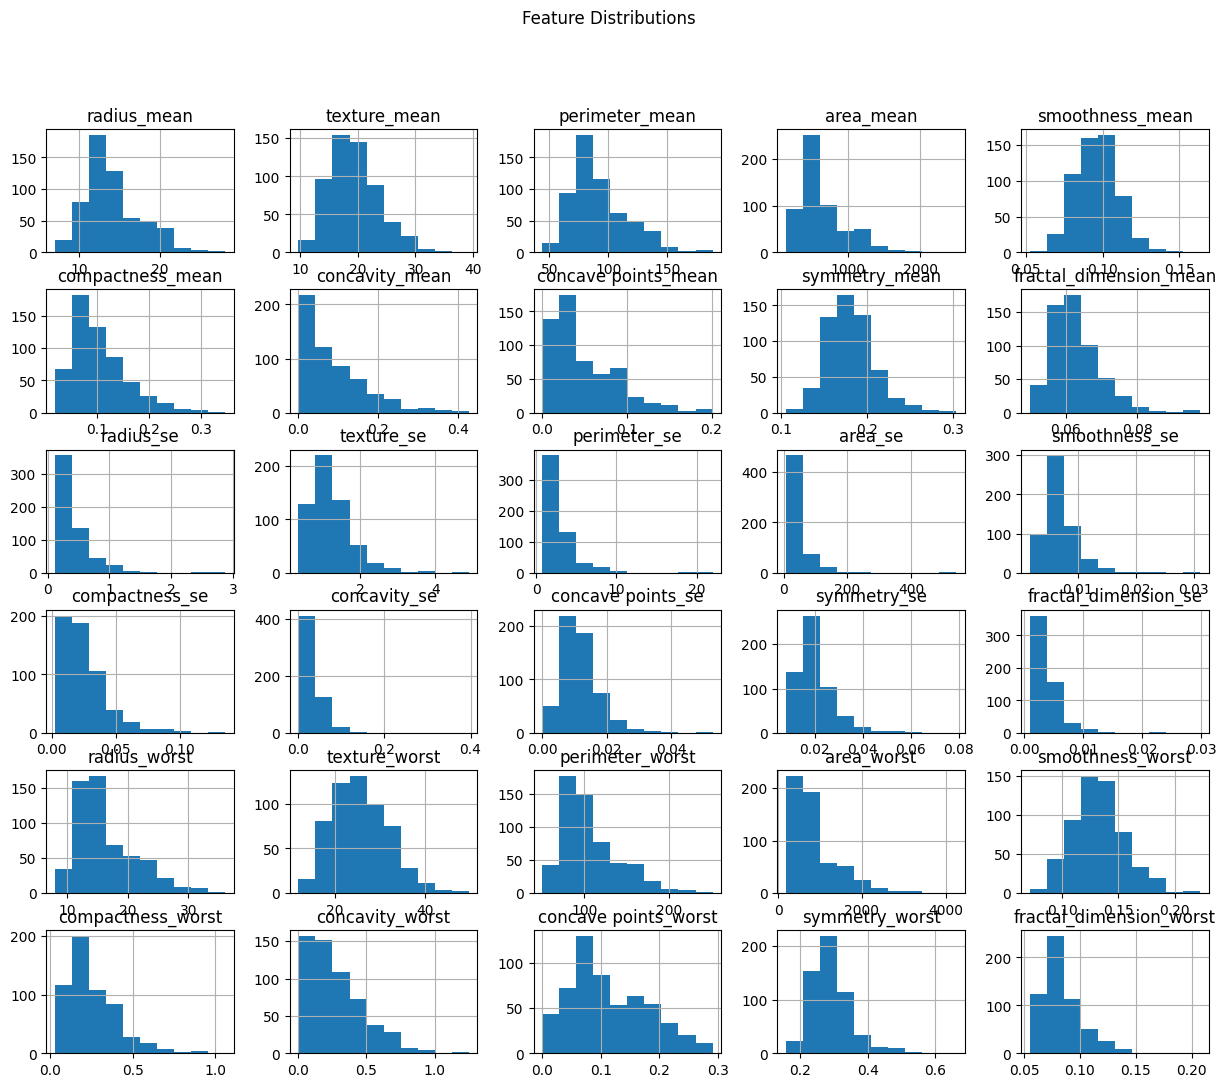

In [ ]:
#Displaying Confusion Matrix as image
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], np.unique(y))
plt.yticks([0, 1], np.unique(y))
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

# =========================
# 9. Visualization: feature histograms
# =========================
X.hist(figsize=(15, 12))
plt.suptitle("Feature Distributions")
plt.show()

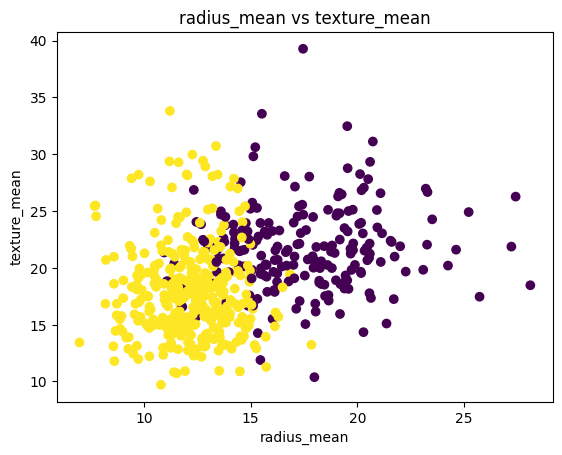

In [ ]:
#Scatterplot visualizations
plt.scatter(data['radius_mean'], data['texture_mean'], c=pd.factorize(y)[0])
plt.xlabel("radius_mean")
plt.ylabel("texture_mean")
plt.title("radius_mean vs texture_mean")
plt.show()

Before adding the line,

```
data = data.drop(columns=['Unnamed: 32'], errors='ignore')
```

the overall model performance of 62.28% is relatively low and indicates that the model is not performing well in classification. The source of the code got around 96% in model accuracy even with the use of the same code and same dataset. This can be because we didn't prepped the data beforehand which is the reason why we added this line.

References:


*   https://www.youtube.com/watch?v=O2L2Uv9pdDA
*   https://www.geeksforgeeks.org/machine-learning/naive-bayes-classifiers/
*   https://www.ibm.com/think/topics/naive-bayes#684929712
*   https://www.youtube.com/watch?v=Yu_eqv8gATs
*   https://github.com/harryconnor/Machine-Learning-From-Scratch/blob/main/Naive_Bayes.ipynb
*   https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data





